## Assignment 4 - Distributed Kalman Filtering

- **Topic:** Distributed state estimation of a target
- **Assessment:** The assignment will go through a pass/fail check.


- **Deadline:** 28-03-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment4_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your group number.



### Instructions
**Installation:** The implementation is tested with python 3.9.21 and packages including
-   numpy version: 2.0.2
-   matplotlib version: 3.9.4


Other (not too old or new) versions will probably also work.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `helper.py` and `linAlg.py`, and the dictionary `model_parameters` as this might result in breaking the assignment.


### AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.

### Personal Information
Please fill in your names and student numbers in the cell below.

In [1]:
# YOUR ANSWER HERE
STUDENT_1_NAME = "Josephine King"
STUDENT_1_STUDENT_NUMBER = "6250513"

STUDENT_2_NAME = "Joost Jaspers"
STUDENT_2_STUDENT_NUMBER = "5372925"

### Description and Objectives

The primary objective of this assignment is to estimate the position of a maneuvering target in 2D using a network of anchors. The target is traveling along an unknown trajectory in two dimensions, within the sensing range of the anchors, which have fixed positions. The anchors can measure the radial distance between themselves and the target throughout its journey, with some noise.

We consider a scenario similar to (but not identical to) the figure shown below. In the figure, a network of fixed-position anchors (blue circles) measures the radial distances (red circles) between themselves and the target (represented as a purple triangle). To estimate the target's position the anchors need to communicate with one another, however, they are only allowed to interact with their immediate neighbors in the network as indicated by the gray dashed lines.

The main focus will be to collaboratively estimate the target's position using distributed state estimation, by implementing a distributed Kalman filter formulation.
\
![alt text](multiagent_tracking.png "Title") 

Each anchor is denoted by an integer $n \in \{1, 2, \dots, N\}$ where $N$ is the number of anchors in the network. 
At each time step $k$, anchors measure the squared distance $(d_k^n)^2 \in \mathbb{R}^+$ between their (fixed) positions $\mathbf{p}^n \in \mathbb{R}^2$ and the target position $\mathbf{p}_k \in \mathbb{R}^2$ as
$$
    d_k^n \triangleq ||\mathbf{p}^n - \mathbf{p}_k ||_2.
$$
Unfortunately the measurement model is nonlinear and not suitable for a standard Kalman filter in this form.
We can however, tweak this formulation to obtain a linear form by squaring the distance and expanding the squared norm as
\begin{aligned}
    (d_k^n)^2 &=  ||\mathbf{p}^n - \mathbf{p}_k ||_2^2 = (\mathbf{p}^n - \mathbf{p}_k)^T (\mathbf{p}^n - \mathbf{p}_k), \\
              &= (\mathbf{p}^n)^T \mathbf{p}^n - 2 (\mathbf{p}^n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    (d_k^n)^2 - (\mathbf{p}^n)^T \mathbf{p}^n &= - 2 (\mathbf{p}^n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    y_k^n &= \tilde{\mathbf{H}}^n \tilde{\mathbf{p}}_k,
\end{aligned}
where $y_k^n \triangleq (d_k^n)^2 - ||\mathbf{p}^n||_2^2, \quad  \tilde{\mathbf{H}}^n \triangleq \begin{bmatrix}  - 2 (\mathbf{p}^n)^T  &  1 \end{bmatrix}, \quad  \tilde{\mathbf{p}}_k \triangleq  \begin{bmatrix} \mathbf{p}_k^T & ||\mathbf{p}_k||_2^2 \end{bmatrix}^T$.
Notice that we added $||\mathbf{p}_k||_2^2$ as a state variable to make this measurement model linear.

To use this approach, let us define the state vector of the target as 
$$ 
\mathbf{x}_k \triangleq \begin{bmatrix} \mathbf{p}_k^T & \dot{\mathbf{p}}_k^T &  ||\mathbf{p}_k||_2^2 \end{bmatrix}^T,
$$
where $ \dot{\mathbf{p}}_k \in \mathbb{R}^2 $ represents the velocity vector.
We can now formulate a state space model to use it for state estimation. 
Denote the state space equations as
\begin{aligned}
    \mathbf{x}_{k+1} &= \mathbf{F} \mathbf{x}_k + \mathbf{w}, \quad \mathbf{w} \sim \mathcal{N}(0, \mathbf{Q}), \\
    y_k^n &= \mathbf{H}^n \mathbf{x}_k + v, \quad v \sim \mathcal{N}(0, R),
\end{aligned}
where we choose the dynamic model matrix $\mathbf{F}$ and $\mathbf{H}^n$ as
\begin{aligned}
    \mathbf{F} &\triangleq \text{blkdiag} \biggl( \begin{bmatrix} 1 & \Delta t_k \\ 0 & 1 \end{bmatrix} \otimes \mathbb{I}_2, 1 \biggr), \\
    \mathbf{H}^n &\triangleq \begin{bmatrix}  - 2 (\mathbf{p}^n)^T & 0 & 0 & 1 \end{bmatrix}, \\
\end{aligned}
and $ \Delta t_k $ is the time difference between time step $k+1$ and $k$.

### Provided data
First let us load the simulated data, the data consists of the following elements
- `dt` $\in \mathbb{R}^+$ (float): Time difference between consecutive time steps
- `T` $\in \mathbb{N}$ (int): Number of time steps
- `edge_list` (list of tuples): Stores the edges as `(i,j)` which denotes the connection between anchors `i` and `j`.
- `anchor_positions` $\in \mathbb{R}^{2 \times N}$ (numpy array): Horizontally stacked anchor position vectors $[\mathbf{p}^1, \ \mathbf{p}^2, \ \dots, \mathbf{p}^N]$ 
- `measurement_list` $\in \mathbb{R}^{N \times T}$ (numpy array): List of measurements $y_k^n$ where `measurement_list[n, k]` denotes the measurement of anchor `n` at time step `k`.
- `true_positions` $\in \mathbb{R}^{2 \times T}$ (numpy array): Horizontally stacked true positions of the target $[\mathbf{p}_1, \ \mathbf{p}_2, \ \dots, \mathbf{p}_T]$ 

After we load the data, let us see what the anchor network, the ground truth trajectory and measurements look like. Note that the measurements plotted as two dimensional points just for clarity. Actual measurements look more like circles since we only measure the radial distances.

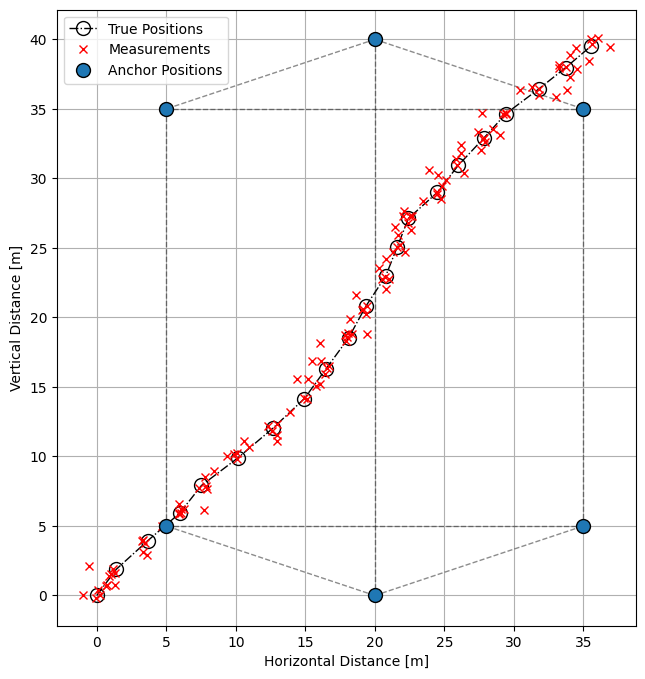

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from linAlg import block_diag
import helper as helper


plt.rcParams.update(
    {
        "lines.linewidth": 1.0,
        "lines.markersize": 10,
        "lines.markeredgewidth": 1.0
        
    }
)
measurement_list, true_states, anchor_positions, edge_list, dt, T, model_parameters = helper.initializeDKFAssignment()

helper.plotMeasurementsAndGroundTruth(true_states, anchor_positions, edge_list, model_parameters)


### Task 1: Construct Matrices
Construct dynamic model matrix $\mathbf{F}$ and measurement model matrices $\mathbf{H}^n$ as described above. 
You can use the parameters `initial_mean` vector,`initial_covariance` matrix, process covariance matrix `Q` and measurement noise variance `R` provided below for the rest of the assignment. 
You can use `block_diag` function to construct $\mathbf{F}$.


### Analysis:
Elaborate on the following:
- Why do we add the new variable $||\mathbf{p}_k||_2^2$ to the state vector? If we wanted to avoid doing this, how would you proceed? 

We add $||\mathbf{p}_k||_2^2$ to the state vector to linearize the system. If we only have $\mathbf{p}_k$ in the state vector, the measurement model is nonlinear in $\mathbf{p}_k$. By including $||\mathbf{p}_k||_2^2$ in the state vector, we can write the measurement model as a linear equation. If we wanted to avoid adding $||\mathbf{p}_k||_2^2$ to the state vector, we could linearize the system locally, resulting in an EKF. We could also use a UKF or a particle filter, as both can handle non-linear models.

- Comment on the dynamic update model of the state variable $||\mathbf{p}_k||_2^2$. Does it properly represent the true dynamics? If not, what can be done to mitigate its drawbacks?

The dynamic update model of $\mathbf{p}_k$ and $||\mathbf{p}_{k}||_2^2$ are: $$\mathbf{p}_{k+1} = \mathbf{p}_k + \Delta t_k \dot{\mathbf{p}}_k + \mathbf{w}_{p}$$ $$||\mathbf{p}_{k+1}||_2^2 = ||\mathbf{p}_k||_2^2 + \mathbf{w}_{||p||^2}$$

According to the dynamic model, $\mathbf{p}_k$ changes over time, while $||\mathbf{p}_{k}||_2^2$ stays constant. This obviously does not represent the true dynamics because it is not consistent with the dynamics of $\mathbf{p}_k$. Furthermore, it violates our assumptions of uncorrelated white Gaussian noise for our state variables. The "noise" in our estimate of $||\mathbf{p}_{k}||_2^2$ is actually correlated with the position and velocity. It therefore does not follow the same Gaussian distribution over time, and may not be zero mean either. 

However, if our time steps are small enough, this linearization of the dynamic model is a pretty good approximation. To mitigate the drawbacks of the model, we can add some more uncertainty to the $Q$ matrix entry corresponding to $||\mathbf{p}_k||_2^2$. This reflects the uncertainty in the value of $||\mathbf{p}_k||_2^2$ after our dynamic update.

In [3]:
F = block_diag(np.kron([[1, dt], [0, 1]], np.eye(2)), 1)
N = 6
dim = 5
H = np.empty((0,dim))
for n in range(0,N):
    Hn = np.concatenate((np.array(-2*anchor_positions[:,n]).T, np.array([0, 0, 1])), axis=0)
    Hn = Hn.reshape(1,dim)
    H = np.concatenate((H, Hn), axis=0)

# Initial Mean and covariance
initial_estimate = np.zeros((5,1))
initial_covariance = np.eye(initial_estimate.shape[0])*100.0

# Process noise covariance (Q) and Measurement noise covariance (R)
Q = np.diag([1.5, 0.15, 1.5, 0.15, 100.0])
R = 0.75


### Task 2: Centralized Kalman Filter Implementation
Implement a centralized version of the Kalman filter by using all measurements generated by the anchors to update the state estimate. After each time step, append your mean and covariance estimates to lists `centralized_means` and `centralized_covariances` respectively.

Note that for the centralized measurement update version you can use an augmented measurement model in the form
\begin{aligned}
    \begin{bmatrix} y_k^1 \\  y_k^2 \\ ... \\  y_k^N \end{bmatrix} &= \begin{bmatrix} \mathbf{H}^1 \\  \mathbf{H}^2 \\ ... \\  \mathbf{H}^N   \end{bmatrix}  \mathbf{x}_k + \mathbf{v}, \quad \mathbf{v} \sim \mathcal{N}(0, R \ \mathbb{I}_N).
\end{aligned}

### Analysis:
Elaborate on the following:
- Comment on the centralized Kalman filter mean estimates. Explain how $||\mathbf{p}_k||_2^2$ is estimated without even measuring the variable itself.

Our measurement model is: $$ y_k^n = \mathbf{H}^n \mathbf{x}_k = \begin{bmatrix}  - 2 (\mathbf{p}^n)^T & 0 & 0 & 1 \end{bmatrix} \mathbf{x}_k = - 2 (\mathbf{p}^n)^T \mathbf{p}_k + ||\mathbf{p}_k||_2^2$$

Solving for $||\mathbf{p}_k||_2^2$, we get 
$$||\mathbf{p}_k||_2^2 = 2 (\mathbf{p}^n)^T \mathbf{p}_k + y_k^n $$

So, if we are confident in our measurement and our estimate of $\mathbf{p}_k$, we can essentially extrapolate what $||\mathbf{p}_k||_2^2$ should be. This is basically what our Kalman filter does. $y_k^n$ has a relatively low noise covariance (0.75), as does $\mathbf{p}_k$ (diag(1.5, 0.15)). Conversely, the noise covariance of $||\mathbf{p}_k||_2^2$ is very high (100). As a result, the Kalman filter has a large covariance for $||\mathbf{p}_k||_2^2$ and a small covariance for $\mathbf{p}_k$ after the dynamic model update. Therefore, during the measurement update, the Kalman filter will trust the values of $y_k^n$ and $\mathbf{p}_k$ much more than $||\mathbf{p}_k||_2^2$. The Kalman gain will reflect this uncertainty in $||\mathbf{p}_k||_2^2$, and result in a measurement update that tunes $||\mathbf{p}_k||_2^2$ to align more closely with the measurement and other state variables.

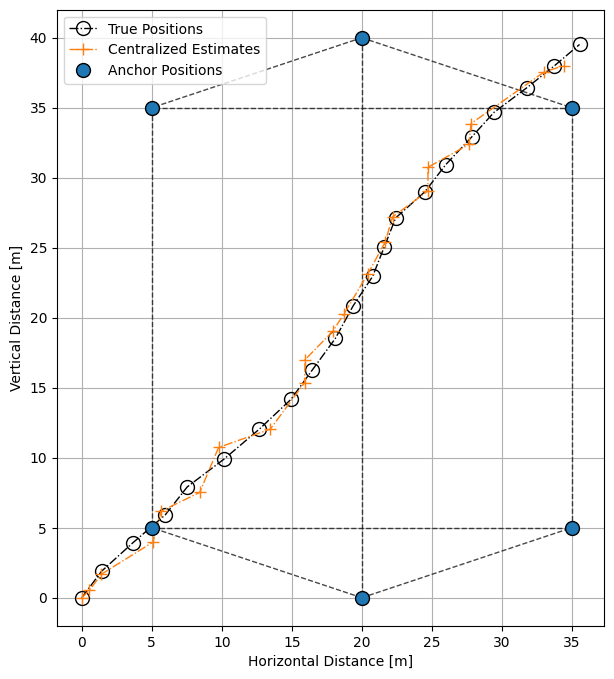

In [4]:
# Centralized estimates
centralized_means = [initial_estimate]
centralized_covariances = [initial_covariance]

for t in range(0, T):
    # Update step
    x = F @ centralized_means[t]
    cov = F @ centralized_covariances[t] @ F.T + Q
    # Correction step
    K = cov @ H.T @ np.linalg.inv(H @ cov @ H.T + R*np.eye(N))
    x = x + K @ (np.reshape(measurement_list[:, t], (N, 1)) - H @ x)
    cov = (np.eye(dim) - K @ H) @ cov
    centralized_means.append(x)
    centralized_covariances.append(cov)

helper.plotCentralizedKFEstimate(true_states, anchor_positions, edge_list, centralized_means)

### Task 3: Distributed Kalman Filter Implementation
Implement a distributed Kalman filter using the formulation given below. After each time step, append your mean and covariance estimates for anchor `n` to lists `local_means[n]` and `local_covariances[n]` respectively.




Assume that anchor $n$ has access to measurements of itself and its neighbors $j \in \mathcal{N}_n \cup \{n\}$.
At time $k$, a local estimate can be computed using the following procedure:

\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = F \hat{x}_{n, k+1 | k}  \\
&P_{n, k+1 | k} = F P_{n, k+1 | k} F^T + Q  \\
\newline
&\text{Measurement Update:} \\
&x_{n,k} = \hat{x}_{n, k | k-1} \\
&P_{n,k} = P_{n, k | k-1} \\
&\text{For each} \ j \in \mathcal{N}_n \ \text{repeat:} \\
& \quad S_{j,k} = H_{j} P_{n,k} H_{j}^T + R_{j} \\
& \quad K_{j,k} = P_{n,k} H_{j}^T S_{j,k}^{-1} \\
& \quad x_{n,k} = x_{n,k} + K_{j,k} (y_{j,k} - H_{j} x_{n,k})\\
& \quad P_{n,k} = P_{n,k} - K_{j,k}  H_{j}  P_{n,k} \\
&\text{end} \\
&\hat{x}_{n, k | k} = x_{n,k} \\
&P_{n, k | k} = P_{n,k} \\
\end{aligned}

Alternatively a more compact from  can be expressed, similar to the information form KF, as
\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = F \hat{x}_{n, k | k}  \\
&P_{n, k+1 | k} = F P_{n, k | k} F^T + Q  \\
\newline
&\text{Measurement Update:} \\
&P_{n,k | k}^{-1} = P_{n,k | k-1}^{-1} + \sum_{j \in \mathcal{N}_n \cup \{n\}} H_{j}^T  R_{j}^{-1}  H_{j}  \\
&\hat{x}_{n, k | k} = \hat{x}_{n,k | k-1} + P_{n,k|k} \sum_{j \in \mathcal{N}_n \cup \{n\}} H_{j}^T R_{j}^{-1} (y_{j, k} - H_{j}\hat{x}_{n,k | k-1}  )\\
\end{aligned}

### Analysis:
Elaborate on the following:
- Analyze the behavior of the decentralized Kalman filter. At a glance, how does it differ from the centralized one?

At a glance, the decentralized Kalman filter performs a bit worse than the centralized Kalman filter. Each node gives a different estimate, rather than the single state estimate that we get from the CKF. Some of the nodes have very good estimates (Node 2) while others have worse measurements (Nodes 1 and 3) that diverge significantly from the true positions. 

- How would the estimates change if you change the number of edges. Comment on what would happen if all edges were removed.

If you add more edges, the decentralized Kalman filter will perform better. If each node is connected to every other node, it'll perform the same as the CKF. If you remove edges, the decentralized Kalman filter will perform worse because each node has less information with which to form an estimate. If all edges were removed, the decentralized Kalman filter will not converge to a good estimate at all. 

- How many neighbors does an anchor need for a feasible solution? In other words, how many neighbors are required for each anchor to estimate a position? You may provide a geometric interpretation.

Each anchor needs at least two neighbors for a feasible position estimate. Each measurement represents the distance of the agent from the node. We can think of this as circles centered on the node, with a radius corresponding to the measurement value. The agent must be somewhere close to the edge of the circle. With just one measurement, the agent could be anywhere on the edge of one circle. With two, we have two intersecting circles, which gives us two feasible positions at their intersecting points. Adding a third circle restricts the position estimate to a small triangle where the three intersect, giving a much better position estimate. 

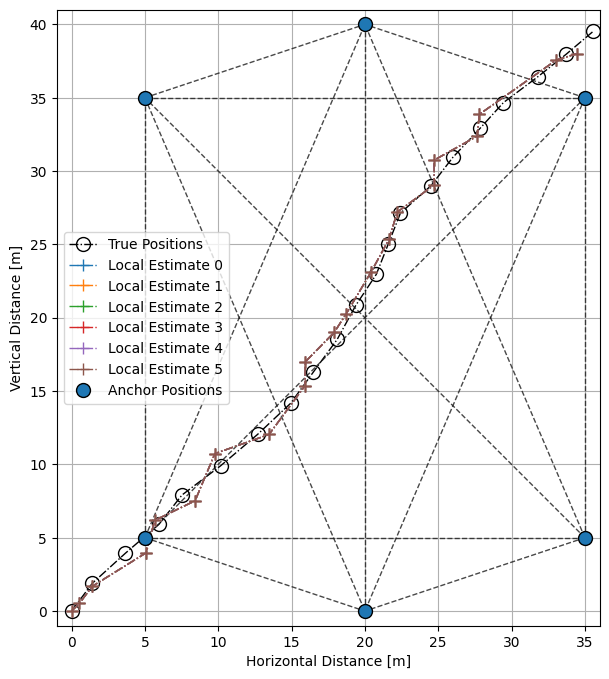

In [ ]:
# Initialize anchor-specific variables
local_means = [[initial_estimate] for _ in range(anchor_positions.shape[1])]
local_covariances = [[initial_covariance] for _ in range(anchor_positions.shape[1])]

# One connection
#edge_list = [[0,4], [1,2], [5,3]]
# Two connections
#edge_list = [[0,4], [4,1], [1,2], [2,5], [5,3], [3,0]]
# Fully connected
#edge_list = [[0,1], [0,2], [0,3], [0,4], [0,5], [1,2], [1,3], [1,4], [1,5], [2,3], [2,4], [2,5], [3,4], [3,5], [4,5]]

adj_matrix = np.zeros((N, N))
for edge in edge_list:
    [i, j]= edge
    adj_matrix[i,j] = 1
    adj_matrix[j,i] = 1

for t in range(0,T):
    for n in range(0, N):
        # Update step
        x = F @ local_means[n][t]
        cov = F @ local_covariances[n][t] @ F.T + Q

        # Correction step
        x_sum = np.zeros((dim, 1))
        cov_sum = np.zeros((dim, dim))
        for j in range(0,N):
            if (adj_matrix[n, j] == 1 or n == j):
                Hj = np.reshape(H[j, :], (1, dim))
                x_sum += np.reshape((1/R) * Hj.T @ (measurement_list[j,t] - (Hj @ x).flatten()), (dim,1))
                cov_sum += (1/R) * Hj.T @ Hj

        cov_inv = np.linalg.inv(cov) + cov_sum
        cov = np.linalg.inv(cov_inv)
        x = x + cov @ x_sum
        local_means[n].append(x)
        local_covariances[n].append(cov)

helper.plotDecentralizedKFEstimate(true_states, anchor_positions, edge_list, local_means)


### Task 4: Comparison
Compute the squared errors of the centralized and local position mean estimates and plot them against time instances. Make sure that the axes are labeled with appropriate units. Also include a legend with descriptive names for each estimate.

### Analysis:
- Compare and discuss the filter performances. 

The centralized Kalman filter performs better than most of the decentralized ones. We can see that the MSE line for the CKF is in the middle of all of the local MSEs, as the CKF aggregrates all of the measurements at each time step together in one estimate. Anchor 2 performs a bit better than the CKF, but that is just for this realization. If we were to run many realizations, on average the CKF will outperform the decentralized Kalman filters. 

- What are the main advantages and disadvantages of centralized and decentralized Kalman filters?

Centralized Kalman filter: <br>
\+ gives an optimal estimate by using all of the measurements in the system <br>
\+ simpler implementation, less computationally complex <br>
\+ can handle correlated noise between nodes <br>
\- single point of failure - if the processing unit fails, the whole state estimation fails <br>
\- communication bottleneck - all sensor data has to be transmitted to a central node <br>
\- scalability - more nodes lead to more measurements and state variables, increasing computational complexity <br>

Decentralized Kalman filter: <br>
\+ avoids single point of failure, resulting in a more robust system <br>
\+ lessened communication burden, as nodes only communicate with neighbors <br>
\+ more scalable, even with more nodes in the system we can have a small state vector, reducing computational complexity <br>
\- suboptimal estimation, as only a subset of the measurements is used <br>
\- assumes a block diagonal R matrix (no correlation of noise between nodes) <br>

CKF average MSE:  3.48
Anchor 0 average MSE:  7420.65
Anchor 1 average MSE:  7420.65
Anchor 2 average MSE:  168.26
Anchor 3 average MSE:  168.26
Anchor 4 average MSE:  489.30
Anchor 5 average MSE:  489.30


/var/folders/ql/c3sy06152ddb023_v8jtctww0000gn/T/ipykernel_49324/1147387657.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  centralized_squared_errors[t] = ((centralized_pos - true_pos)**2).mean(axis=0)
/var/folders/ql/c3sy06152ddb023_v8jtctww0000gn/T/ipykernel_49324/1147387657.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  local_squared_errors[anchor, t] = ((local_pos - true_pos)**2).mean(axis=0)  # Squared error


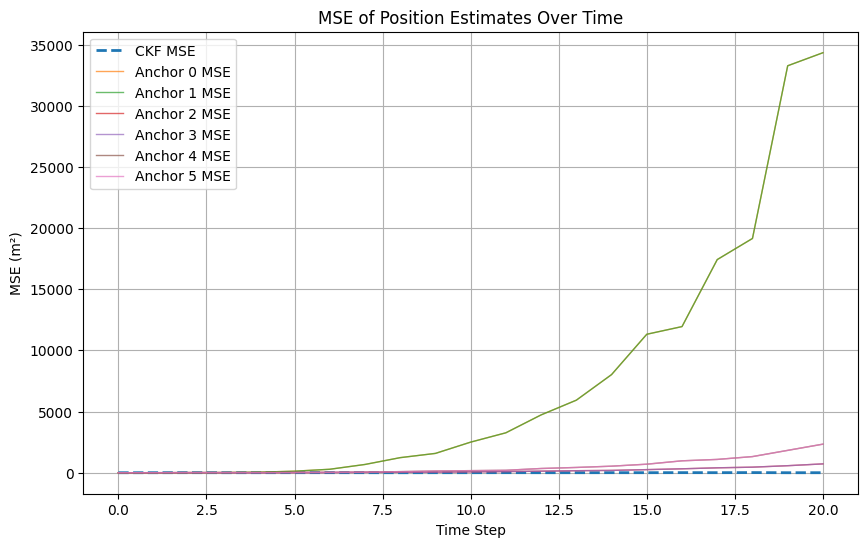

In [6]:
# Initialize squared error arrays
local_squared_errors = np.zeros((N, T+1))
centralized_squared_errors = np.zeros(T+1)

# Compute squared errors
for t in range(T+1):
    centralized_pos = centralized_means[t][0:2]
    true_pos = np.reshape(true_states[0:2,t], (2,-1))
    centralized_squared_errors[t] = ((centralized_pos - true_pos)**2).mean(axis=0)
    for anchor in range(N):
        local_pos = local_means[anchor][t][0:2]
        local_squared_errors[anchor, t] = ((local_pos - true_pos)**2).mean(axis=0)  # Squared error

# Plot squared errors
time_values = np.arange(T+1)
plt.figure(figsize=(10, 6))
plt.plot(time_values, centralized_squared_errors, label="CKF MSE", linestyle="--", linewidth=2)
for anchor in range(N):
    plt.plot(time_values, local_squared_errors[anchor], label=f"Anchor {anchor} MSE", alpha=0.7)

print("CKF average MSE: ", "{:.2f}".format(round(centralized_squared_errors.mean(), 2)) )
for anchor in range(N):
    print(f"Anchor {anchor} average MSE: ", "{:.2f}".format(round(local_squared_errors[anchor].mean(), 2)))

# Add labels
plt.xlabel("Time Step")
plt.ylabel("MSE (m²)")
plt.title("MSE of Position Estimates Over Time")
plt.legend()
plt.grid(True)

plt.show()


#### Feedback:
This is the first year we are teaching this course. Your feedback will be invaluable in improving it for the coming years. Please let us know in this markdown any comments, suggestions or errors you have encountered in the last three assignments.  

So far, the course has been really nice. We learn a lot from the assignments and they're also quite fun. It's a nice way for us to apply what we've learned in the lecture in a practical way. The spacing of the deadlines requires us to stay on top of the course material without falling behind. The exercise sessions are very helpful, the TAs are very good. 

For the first two labs, it would have been nice to see some cases with non-Gaussian noise. This would illustrate the use cases for UKF, particle filter, and EKF a bit more clearly. Also, it's not really clear how we should model our noise in real life applications. It could be nice if the first two assignments include some component related to modeling noise from sensor data. 
